# Wide Receiver Opportunity and Following-Game PPR

## tl;dr

This notebook compares how strongly previous-game, three-game, and five-game
averages relate to a wide receiver's following-game PPR production. It uses
2021–2024 data only; 2025 remains the untouched final test season.

Across 5,575 identical eligible WR appearances, longer windows produced
stronger relationships with following-game PPR for every metric. The five-game
PPR average had the highest correlation (`0.558`), followed extremely closely
by five-game target share (`0.556`). Five-game air-yard share was weaker on its
own (`0.488`).

This descriptive result supports the five-game-window portion of the
hypothesis, but it does not yet show that opportunity metrics outperform recent
fantasy scoring. Forecast-error testing is still required.

## Context & Methods

Our preregistered hypothesis predicts that five-game rolling target share and
air-yard share will be more useful than the previous game's fantasy score.

### Key Assumptions

- One row represents one listed regular-season WR appearance.
- Zero-target appearances remain in rolling histories.
- Missed scheduled weeks are not inserted as zero games.
- Rolling values are shifted so the current game never predicts itself.
- All window comparisons use rows with a complete five-game same-season history.
- Correlation measures association, not prediction accuracy or causation.

## Data

### 1. Load the analysis-ready player-week table

In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "work" / "matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "wr_weekly_features.csv"
FIGURE_PATH = PROJECT_ROOT / "reports" / "figures" / "rolling_window_correlations.png"

all_receiver_weeks = pd.read_csv(DATA_PATH, low_memory=False)
development_weeks = all_receiver_weeks.loc[
    all_receiver_weeks["season"].between(2021, 2024)
].copy()

eligible_weeks = development_weeks.loc[
    development_weeks["rolling_5_target_share"].notna()
].copy()

print(f"Development WR appearances: {len(development_weeks):,}")
print(f"Identical eligible appearances: {len(eligible_weeks):,}")
print(f"Seasons analyzed: {eligible_weeks['season'].min()}–{eligible_weeks['season'].max()}")
assert eligible_weeks["season"].max() == 2024
assert not (eligible_weeks["season"] == 2025).any()

Development WR appearances: 9,769
Identical eligible appearances: 5,575
Seasons analyzed: 2021–2024


### 2. Confirm the comparison population

Every window is compared on the same eligible player-games. This avoids giving
shorter windows an advantage from having more early-season observations.

In [2]:
population_by_season = (
    eligible_weeks.groupby("season")
    .size()
    .rename("eligible_player_games")
    .to_frame()
)
population_by_season

,eligible_player_games
season,
2021,1378
2022,1348
2023,1473
2024,1376


## Results

### 3. Measure association with following-game PPR

In [3]:
window_rows = []
for window in (1, 3, 5):
    for metric, label in (
        ("fantasy_points_ppr", "PPR points"),
        ("target_share", "Target share"),
        ("air_yards_share", "Air-yard share"),
    ):
        feature = f"rolling_{window}_{metric}"
        correlation = eligible_weeks[feature].corr(
            eligible_weeks["fantasy_points_ppr"]
        )
        window_rows.append(
            {
                "window": window,
                "metric": label,
                "correlation_with_following_game_ppr": correlation,
            }
        )

correlations = pd.DataFrame(window_rows)
correlation_table = correlations.pivot(
    index="metric",
    columns="window",
    values="correlation_with_following_game_ppr",
).rename(columns={1: "Previous game", 3: "Previous 3 games", 5: "Previous 5 games"})

correlation_table.round(3)

window,Previous game,Previous 3 games,Previous 5 games
metric,,,
Air-yard share,0.397,0.469,0.488
PPR points,0.434,0.535,0.558
Target share,0.484,0.544,0.556


### 4. Visualize how the rolling window changes each relationship

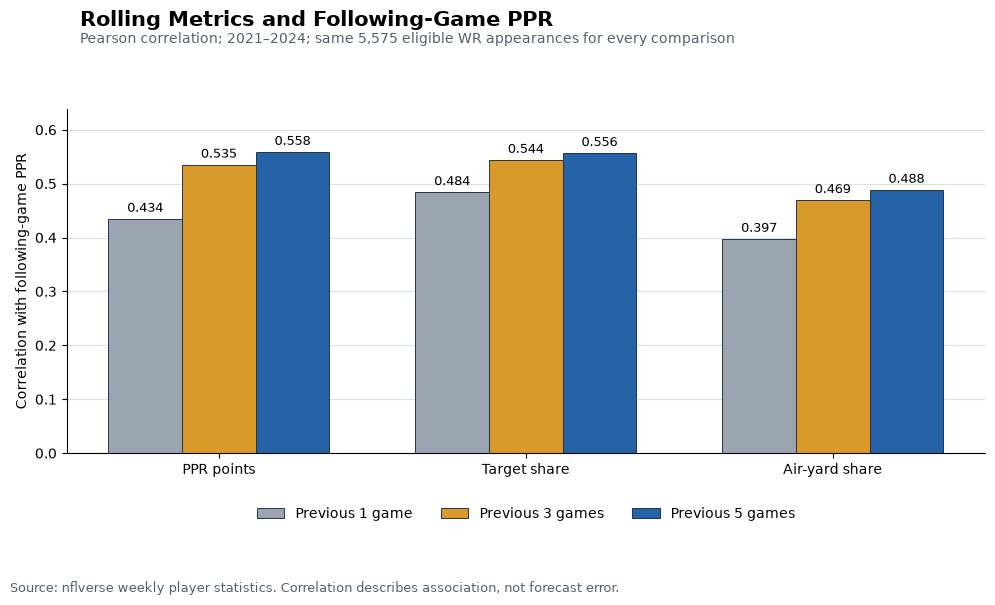

In [4]:
metric_order = ["PPR points", "Target share", "Air-yard share"]
window_order = [1, 3, 5]
colors = {1: "#9AA5B1", 3: "#D99A2B", 5: "#2563A6"}

fig, ax = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(metric_order))
bar_width = 0.24

for index, window in enumerate(window_order):
    values = [
        correlations.loc[
            (correlations["metric"] == metric)
            & (correlations["window"] == window),
            "correlation_with_following_game_ppr",
        ].iloc[0]
        for metric in metric_order
    ]
    offsets = x_positions + (index - 1) * bar_width
    bars = ax.bar(
        offsets,
        values,
        width=bar_width,
        color=colors[window],
        edgecolor="#243447",
        linewidth=0.7,
        label=f"Previous {window} game" + ("" if window == 1 else "s"),
    )
    ax.bar_label(bars, labels=[f"{value:.3f}" for value in values], padding=3, fontsize=9)

fig.suptitle(
    "Rolling Metrics and Following-Game PPR",
    x=0.08,
    y=0.98,
    ha="left",
    fontsize=15,
    weight="bold",
)
fig.text(
    0.08,
    0.925,
    f"Pearson correlation; 2021–2024; same {len(eligible_weeks):,} eligible WR appearances for every comparison",
    fontsize=10,
    color="#52606D",
)
ax.set_ylabel("Correlation with following-game PPR")
ax.set_xticks(x_positions)
ax.set_xticklabels(metric_order)
ax.set_ylim(0, max(0.55, correlations["correlation_with_following_game_ppr"].max() + 0.08))
ax.grid(axis="y", color="#D9E2EC", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.text(
    0.01,
    0.01,
    "Source: nflverse weekly player statistics. Correlation describes association, not forecast error.",
    fontsize=9,
    color="#52606D",
)
fig.tight_layout(rect=(0, 0.07, 1, 0.90))
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_PATH, dpi=180, bbox_inches="tight")
plt.show()

## Takeaways

The chart should be interpreted in two stages:

1. Compare windows within each metric.
2. Compare the opportunity metrics with the PPR-score baseline.

- The five-game window produced the strongest correlation for all three metric
  families.
- Five-game PPR (`0.558`) and five-game target share (`0.556`) were effectively
  tied at this descriptive stage.
- Five-game air-yard share (`0.488`) had a meaningful but weaker standalone
  relationship.
- Correlation alone does not determine the winning predictive model. The next
  stage will compare forecast error using time-aware models and the 2024
  validation season.